In [ ]:
try:
    import convokit
except ModuleNotFoundError:
    !pip install convokit

In [ ]:
import convokit
from convokit import Corpus, download

/usr/local/lib/python3.8/dist-packages/torch/cuda/__init__.py:497: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [ ]:
corpus = Corpus(filename=download("reddit-corpus-small"))

in total 288846 comments
-776 42837
percentile 10 0.0
percentile 25 1.0
percentile 50 2.0
percentile 75 7.0
percentile 90 24.0
mean 20.547135844013766
top 0.1 percent accounts for 25.221020940670513 percent of total scores
top 0.5 percent accounts for 45.34554414706894 percent of total scores
top 1 percent accounts for 55.15338103487842 percent of total scores
top 5 percent accounts for 78.14173242675011 percent of total scores
top 10 percent accounts for 86.97714457288494 percent of total scores


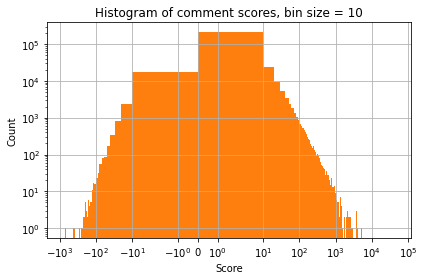

In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline
from matplotlib import pyplot as plt

# basic metrics
all_comments = [utt for utt in corpus.iter_utterances() if utt.meta['top_level_comment']]
print("in total", len(all_comments), "comments")

s = [comment.meta['score'] for comment in all_comments]
print(min(s), max(s))
percentiles = [10, 25, 50, 75, 90]
for x, p in zip(np.percentile(s, percentiles), percentiles):
    # plt.axvline(x=x, label='{} percentile'.format(p))
    print('percentile', p, x)
print('mean', np.mean(s))
sorted_scores = sorted(s, reverse=True)
sorted_len = len(sorted_scores)
print('top 0.1 percent accounts for', sum(sorted_scores[:sorted_len//1000])/sum(s)*100, 'percent of total scores')
print('top 0.5 percent accounts for', sum(sorted_scores[:sorted_len//200])/sum(s)*100, 'percent of total scores')
print('top 1 percent accounts for', sum(sorted_scores[:sorted_len//100])/sum(s)*100, 'percent of total scores')
print('top 5 percent accounts for', sum(sorted_scores[:sorted_len//20])/sum(s)*100, 'percent of total scores')
print('top 10 percent accounts for', sum(sorted_scores[:sorted_len//10])/sum(s)*100, 'percent of total scores')
binsize = 10
bins = range(min(s)//5*5, max(s)//5*5, binsize)
n, bins, patches = plt.hist(s, bins=bins, density=False, facecolor='tab:orange')
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Histogram of comment scores, bin size = {}'.format(binsize))
# plt.text(60, .025, r'$\mu=100,\ \sigma=15$')
plt.xscale('symlog')
plt.yscale('log')
plt.grid(True)
# plt.legend()
plt.tight_layout()
plt.savefig("/tmp/fig1.pdf")

In [ ]:
# relative time vs score

all_comments = [utt for utt in corpus.iter_utterances() if utt.meta['top_level_comment']]
buckets = [5, 10, 20, 60, 3*60, 12*60, 24*60]
bins = [[] for _ in range(len(buckets)+1)]
for comment in all_comments:
  try:
    relative_time = comment.timestamp - comment.get_conversation().meta['timestamp']
    for i in range(len(buckets)):
      if relative_time < buckets[i] * 60:
        bins[i].append(comment.meta['score'])
        break
    else:
      bins[-1].append(comment.meta['score'])
  except:
    pass

for bin, bucket in zip(bins, buckets+['more']):
  ps = np.percentile(bin, (1,25,50,75,99))
  for p in ps:
    print(f'{p:.1f}', sep='\t', end='\t')
  print(f'{np.mean(bin):.1f}')



-28.0	2.0	15.0	74.0	1939.5	132.6
-25.0	1.0	5.0	28.8	1328.1	79.4
-26.0	1.0	3.0	17.0	1358.1	66.9
-29.0	1.0	3.0	18.0	1093.4	71.5
-22.0	1.0	4.0	16.0	643.0	39.8
-14.0	1.0	2.0	7.0	187.0	13.9
-5.0	1.0	1.0	3.0	31.0	3.1
-1.0	1.0	1.0	2.0	10.0	1.6


In [ ]:
# num of tokens vs score
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'\w+')

all_comments = [utt for utt in corpus.iter_utterances() if utt.meta['top_level_comment']]
buckets = [5, 10, 20, 50, 100, 200, 400]
bins = [[] for _ in range(len(buckets)+1)]
for comment in all_comments:
  if '[deleted]' in comment.text:
    continue
  try:
    value = len(tokenizer.tokenize(comment.text))
    for i in range(len(buckets)):
      if value <= buckets[i]:
        bins[i].append(comment.meta['score'])
        break
    else:
      bins[-1].append(comment.meta['score'])
  except:
    pass

for bin, bucket in zip(bins, buckets+['more']):
  ps = np.percentile(bin, (1,25,50,75,99))
  for p in ps:
    print(f'{p:.1f}', sep='\t', end='\t')
  print(f'{np.mean(bin):.1f}')


-15.0	1.0	2.0	5.0	229.0	15.7
-13.0	1.0	2.0	8.0	339.0	23.6
-14.0	1.0	2.0	8.0	345.0	23.4
-14.0	1.0	2.0	7.0	319.0	20.8
-14.0	1.0	2.0	7.0	286.0	21.1
-12.0	1.0	2.0	6.0	247.0	18.8
-11.0	1.0	2.0	7.0	344.9	46.2
-8.0	1.0	1.0	5.0	326.0	20.7


In [ ]:
# keywords
import nltk
import random
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'\w+')
bigram_measures = nltk.collocations.BigramAssocMeasures()

all_comments = [(utt, utt.meta['score']) for utt in corpus.iter_utterances() if utt.meta['top_level_comment'] and '[deleted]' not in utt.text]
sorted_by_score = sorted(all_comments, key=lambda c:c[1], reverse=True)
freq = nltk.FreqDist([w.lower() for c in all_comments for w in tokenizer.tokenize(c[0].text)])

def keywords(sub_tokens):
    sub_freq = nltk.FreqDist([w.lower() for w in sub_tokens if w.isalpha()])
    keyness = nltk.FreqDist()
    for w in sub_freq:
        if sub_freq[w] > 100:
            if sub_freq[w] > sub_freq.N() / freq.N() * freq[w]:
                keyness[w] = bigram_measures.likelihood_ratio(sub_freq[w], (freq[w], sub_freq.N()), freq.N())
    return keyness

print("top 10%:")
print(list(k[0] for k in keywords([w.lower() for c in sorted_by_score[:len(sorted_by_score)//10] for w in tokenizer.tokenize(c[0].text)]).most_common(50)))

print("bottom 10%:")
print(list(k[0] for k in keywords([w.lower() for c in sorted_by_score[-len(sorted_by_score)//10:] for w in tokenizer.tokenize(c[0].text)]).most_common(50)))


top 10%:
['he', 'she', 'her', 'click', 'his', 'this', 'was', 'him', 'edit', 'imgur', 'a', 'had', 'fucking', 'husband', 'mom', 'guy', 'me', 's', 'dad', 'fuck', 'my', 'blood', 'told', 'wife', 'girl', 'and', 'movie', 'when', 'friend', 'got', 'woman', 'episode', 'face', 'door', 'shit', 'old', 'scene', 'in', 'love', 'man', 'up', 'day', 'after', 'turns', 'car', 'ex', 'feel', 'together', 'kids', 'dog']
bottom 10%:
['you', 'trump', 'not', 'people', 't', 'is', 'are', 'no', 'gt', 'women', 'racist', 'why', 'saying', 'downvotes', 'republican', 'men', 'fuck', 'fucking', 'opinion', 'stop', 'game', 'stupid', 'wrong', 'downvoted', 'shit', 'who', 'don', 'because', 'downvote', 'russia', 'being', 'nazis', 'what', 'democrats', 'edit', 'country', 'support', 'obama', 'bullshit', 'dont', 'israel', 're', 'your', 'fact', 'investigation', 'comment', 'vote', 'white', 'political', 'news']


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

def sentiment(utter):
  sid = SentimentIntensityAnalyzer()
  return sid.polarity_scores(utter)

def print_perc(percentiles):
  for p in percentiles:
    print(f'{p:.2f}', sep='\t', end='\t')

def group_sentiment(utters):
  percs = [10, 25, 50, 75, 90]
  ss = [sentiment(u) for u in utters]
  neg = [s['neg'] for s in ss]
  neu = [s['neu'] for s in ss]
  pos = [s['pos'] for s in ss]
  compound = [s['compound'] for s in ss]
  print("neg:", end='')
  print_perc(np.percentile(neg, percs))
  print(f'{np.mean(neg):.2f}')

  print("neu:", end='')
  print_perc(np.percentile(neu, percs))
  print(f'{np.mean(neu):.2f}')

  print("pos:", end='')
  print_perc(np.percentile(pos, percs))
  print(f'{np.mean(pos):.2f}')

  print("compound:", end='')
  print_perc(np.percentile(compound, percs))
  print(f'{np.mean(compound):.2f}')

top10p = [c for c in sorted_by_score[:len(sorted_by_score)//10]]
print('top10p:')
group_sentiment(c[0].text for c in top10p)
print()
bottom10p = [c for c in sorted_by_score[-len(sorted_by_score)//10:]]
print('bottom10p:')
group_sentiment(c[0].text for c in bottom10p)


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


top10p:
neg:0.00	0.00	0.02	0.14	0.26	0.09
neu:0.56	0.69	0.81	1.00	1.00	0.79
pos:0.00	0.00	0.08	0.18	0.31	0.12
compound:-0.66	-0.27	0.00	0.45	0.76	0.06

bottom10p:
neg:0.00	0.00	0.06	0.16	0.27	0.10
neu:0.56	0.69	0.80	0.94	1.00	0.78
pos:0.00	0.00	0.07	0.17	0.28	0.11
compound:-0.74	-0.37	0.00	0.40	0.73	0.01
